# PRJEB67638 - Espinosa-Gongora et al.

Article link: [https://pmc.ncbi.nlm.nih.gov/articles/PMC10655203/](https://pmc.ncbi.nlm.nih.gov/articles/PMC10655203/).

In [1]:
suppressPackageStartupMessages({
    library(provoc)
    library(here)
    library(ggplot2)
    library(lubridate)
})

prj <- "PRJEB67638"
lineages_in_paper <- c("BA.2.75", "BA.5", "XBB.1.5", "BA.2", "BA.2.86", "XBB")


In [2]:
coco <- read.csv(
    here(
        "data/processed/",
        paste0(prj, "_processed.csv.gz")
    )
)
coco$mutation <- parse_mutations(coco$label)
head(coco)


  position    label    mutation   frequency coverage count         sra       date    sample_name avg_spot_len      bases bioproject        location      lat      lon
1    10386 +10387.T ins:10387:1 0.135139722    17678  2389 ERR12141773 2023-08-28 SAMEA114518906          170 1059322320 PRJEB67638 Kungsängsverket 59.84486 17.65987
2    10527 +10528.T ins:10528:1 0.045883941     2964   136 ERR12141773 2023-08-28 SAMEA114518906          170 1059322320 PRJEB67638 Kungsängsverket 59.84486 17.65987
3     1093  +1094.T  ins:1094:1 0.001899078    11058    21 ERR12141773 2023-08-28 SAMEA114518906          170 1059322320 PRJEB67638 Kungsängsverket 59.84486 17.65987
4    11074 +11075.T ins:11075:1 0.118620899    19752  2343 ERR12141773 2023-08-28 SAMEA114518906          170 1059322320 PRJEB67638 Kungsängsverket 59.84486 17.65987
5    11095 +11096.T ins:11096:1 0.038000406    19684   748 ERR12141773 2023-08-28 SAMEA114518906          170 1059322320 PRJEB67638 Kungsängsverket 59.84486 17.65987
6   

In [3]:
barcodes <- provoc::usher_barcodes()
print("Lineages not in barcodes:")
print(setdiff(lineages_in_paper, rownames(barcodes)))
available_lineages <- intersect(lineages_in_paper, rownames(barcodes))
barcodes <- filter_lineages(barcodes, available_lineages)
dim(barcodes)


[1] "Lineages not in barcodes:"
character(0)


[1]   6 144

In [4]:
system.time(
    res <- provoc(count / coverage ~ .,
        data = coco,
        lineage_defs = barcodes,
        by = "sra")
)
head(res)


Warning messages:
1: In rep(10, length = nrow(lineage_defs)) :
  first element used of 'length.out' argument
2: In optim(theta.old, fun, gradient, control = control, method = method,  :
  one-dimensional optimization by Nelder-Mead is unreliable:
use "Brent" or optimize() directly
3: In optim(theta.old, fun, gradient, control = control, method = method,  :
  one-dimensional optimization by Nelder-Mead is unreliable:
use "Brent" or optimize() directly
4: In optim(theta.old, fun, gradient, control = control, method = method,  :
  one-dimensional optimization by Nelder-Mead is unreliable:
use "Brent" or optimize() directly
5: In optim(theta.old, fun, gradient, control = control, method = method,  :
  one-dimensional optimization by Nelder-Mead is unreliable:
use "Brent" or optimize() directly


Call: count/coverage ~ .

Mutations in lineage definitions:  144 
Summary of percent of mutations in data used:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.02313 0.02313 0.02313 0.02313 0.02313 0.02313 

All models converged.

Top 6 lineages:
     rho ci_low ci_high lineage         sra       date    sample_name avg_spot_len      bases bioproject        location  lat  lon
2  0.817     NA      NA XBB.1.5 ERR12141773 2023-08-28 SAMEA114518906          170 1059322320 PRJEB67638 Kungsängsverket 59.8 17.7
3  0.075     NA      NA     XBB ERR12141773 2023-08-28 SAMEA114518906          170 1059322320 PRJEB67638 Kungsängsverket 59.8 17.7
5  0.054     NA      NA    BA.2 ERR12141773 2023-08-28 SAMEA114518906          170 1059322320 PRJEB67638 Kungsängsverket 59.8 17.7
1  0.011     NA      NA BA.2.86 ERR12141773 2023-08-28 SAMEA114518906          170 1059322320 PRJEB67638 Kungsängsverket 59.8 17.7
4  0.008     NA      NA BA.2.75 ERR12141773 2023-08-28 SAMEA114518906          170 1059322320 P

Ignoring unknown labels:
• fill : "Lineage"


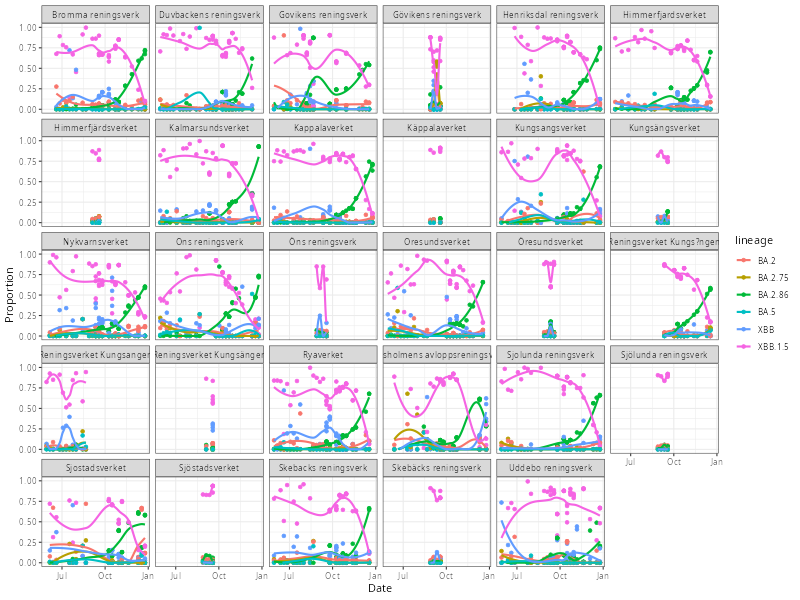

In [5]:
options(repr.plot.width = 15, repr.plot.height = 12)

res$date <- lubridate::ymd(res$date)

gg <- autoplot(res, date_col = "date") + facet_wrap(~location) +
    geom_smooth(formula = y ~ x, se = FALSE, method = "loess") +
    theme_bw()
suppressWarnings(print(gg))
